# 06 — Association Rules Conditioner: Soft Diagnostic Prior

**Idea:** Use co-occurrence patterns mined from training labels to inject a soft diagnostic prior
into the prompt at inference time. The prior tells the model which findings are statistically
likely given the clinical indication — nudging generation without hard-coding any output.

**Mechanism (two-tier):**
1. Build a pairwise conditional probability table P(B | A) from training labels (kept as fallback).
2. Build a TF-IDF index over training indications. For each test study, retrieve the k=20 most
   similar training studies by indication and compute the empirical label prevalence over that
   neighborhood — a data-driven alternative to hand-coded keyword rules.
3. **Primary path**: if retrieval similarity ≥ 0.05, inject the neighborhood label distribution:
   *"Clinical context: Cardiomegaly present in 67% of similar cases, Edema in 42%..."*
4. **Fallback path**: if retrieval fails (empty indication or low similarity), scan the indication
   for keyword triggers and inject matching pairwise association rules.
5. The selected hint is injected into the prompt after the system instruction, before `Findings:`.

Saves `reports/eval_metrics_assoc_rules_{VARIANT}.json` for notebook 04 STEP 7.

**Execution order across notebooks:**
```
04 (core eval)  →  05 (RAG)  →  [this notebook]  →  04 STEP 7 (grand comparison)
```

## STEP 1 — Environment setup

In [1]:
import os, sys, json, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml

matplotlib.rcParams['figure.dpi'] = 120
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR  = REPO_ROOT / 'data' / 'processed'
CHECKPOINT_DIR = REPO_ROOT / 'checkpoints'
FIGURES_DIR    = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(REPO_ROOT / 'params.yaml') as f:
    params = yaml.safe_load(f)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}  {props.total_memory/1e9:.1f} GB')

test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
test_df = test_df[test_df['findings'].notna() & (test_df['findings'].str.strip() != '')].reset_index(drop=True)
references = test_df['findings'].str.strip().tolist()
print(f'Test set : {len(test_df)} studies')

train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
train_df = train_df[train_df['findings'].notna() & (train_df['findings'].str.strip() != '')].reset_index(drop=True)
print(f'Train set: {len(train_df)} studies')

env_file = REPO_ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())
    import huggingface_hub
    hf_token = os.environ.get('HF_TOKEN')
    if hf_token:
        huggingface_hub.login(token=hf_token, add_to_git_credential=False)
        print('HF: logged in')

Device : cuda
GPU    : NVIDIA RTX 4000 Ada Generation  21.0 GB
Test set : 600 studies
Train set: 2403 studies


/home/jvazquez/diego_villalba/ReportCXR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
WARNING Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF: logged in


## STEP 2 — Build association rules from training labels

Computes pairwise P(B | A) and lift for all label pairs with prevalence ≥ 1%.  
CPU-only — runs immediately without a GPU.

Total rules      : 110
conf ≥ 0.30      : 8
conf ≥ 0.30 + lift ≥ 1.5: 8



,antecedent,consequent,support,confidence,lift,p_antecedent
41,Edema,Cardiomegaly,0.0079,0.6129,4.9258,0.0129
52,Atelectasis,Lung Opacity,0.0362,0.5370,3.9830,0.0674
62,Pleural Effusion,Lung Opacity,0.0141,0.4474,3.3180,0.0316
42,Edema,Lung Opacity,0.0050,0.3871,2.8710,0.0129
72,Pleural Other,Lung Opacity,0.0050,0.3429,2.5429,0.0146
61,Pleural Effusion,Cardiomegaly,0.0104,0.3289,2.6437,0.0316
45,Edema,Pleural Effusion,0.0042,0.3226,10.1995,0.0129
0,Enlarged Cardiomediastinum,Cardiomegaly,0.0225,0.3017,2.4245,0.0745


Saved assoc_rules_heatmap.png


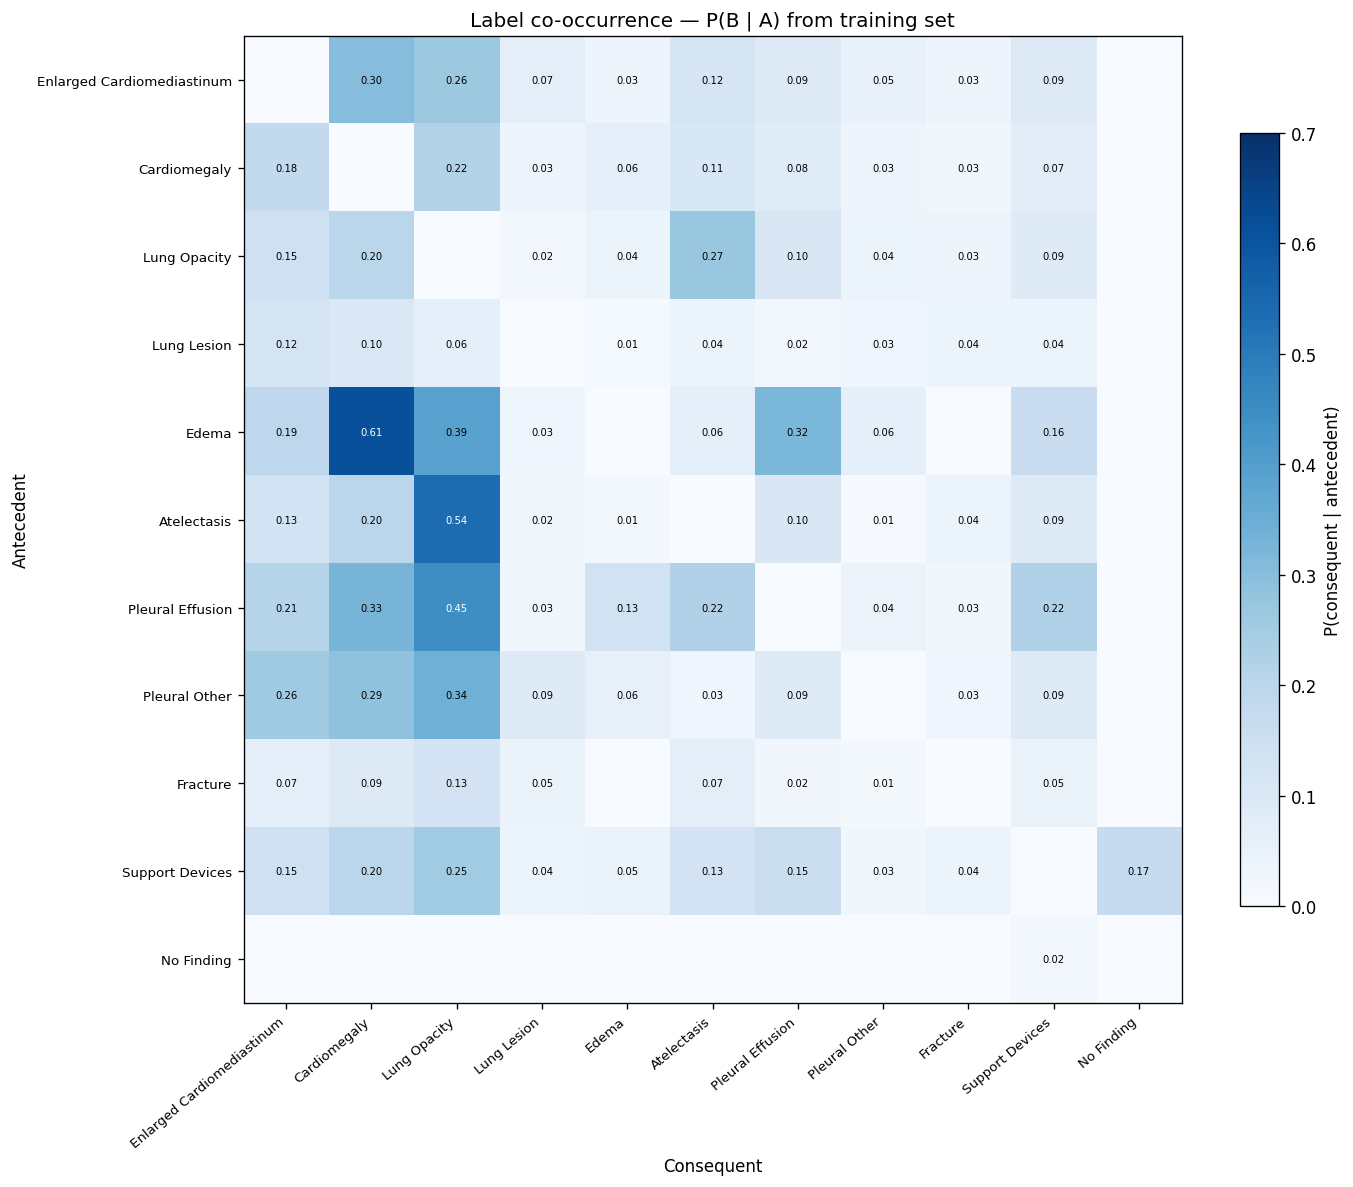

TF-IDF label-prior index: 2403 docs × 3329 features


In [2]:
from src.data.labels import CHEXBERT_LABELS

train_label_matrix = train_df[CHEXBERT_LABELS].values.astype(float)
n = len(train_label_matrix)

co_matrix   = (train_label_matrix.T @ train_label_matrix) / n
prevalences = train_label_matrix.mean(axis=0)

rules = []
for i, label_a in enumerate(CHEXBERT_LABELS):
    if prevalences[i] < 0.01: continue
    for j, label_b in enumerate(CHEXBERT_LABELS):
        if i == j or prevalences[j] < 0.01: continue
        p_a  = prevalences[i]
        p_ab = co_matrix[i, j]
        conf = p_ab / p_a
        lift = conf / prevalences[j] if prevalences[j] > 0 else 0
        rules.append({
            'antecedent':   label_a,
            'consequent':   label_b,
            'support':      round(float(p_ab),  4),
            'confidence':   round(float(conf),  4),
            'lift':         round(float(lift),  4),
            'p_antecedent': round(float(p_a),   4),
        })

rules_df = pd.DataFrame(rules).sort_values('confidence', ascending=False)
print(f'Total rules      : {len(rules_df)}')
print(f'conf ≥ 0.30      : {(rules_df.confidence >= 0.30).sum()}')
print(f'conf ≥ 0.30 + lift ≥ 1.5: {((rules_df.confidence >= 0.30) & (rules_df.lift >= 1.5)).sum()}')
print()
display(rules_df[rules_df['confidence'] >= 0.30].head(25))

# ── Heat-map of conditional probabilities ─────────────────────────────────────
labels_active = [l for i, l in enumerate(CHEXBERT_LABELS) if prevalences[i] >= 0.01]
active_idx    = [CHEXBERT_LABELS.index(l) for l in labels_active]
conf_matrix   = np.zeros((len(labels_active), len(labels_active)))
for i, ia in enumerate(active_idx):
    for j, ja in enumerate(active_idx):
        if ia != ja and prevalences[ia] > 0:
            conf_matrix[i, j] = co_matrix[ia, ja] / prevalences[ia]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(conf_matrix, cmap='Blues', vmin=0, vmax=0.7, aspect='auto')
ax.set_xticks(range(len(labels_active)))
ax.set_xticklabels(labels_active, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(labels_active)))
ax.set_yticklabels(labels_active, fontsize=8)
for i in range(len(labels_active)):
    for j in range(len(labels_active)):
        if conf_matrix[i, j] > 0:
            ax.text(j, i, f'{conf_matrix[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if conf_matrix[i, j] > 0.4 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8, label='P(consequent | antecedent)')
ax.set_xlabel('Consequent'); ax.set_ylabel('Antecedent')
ax.set_title('Label co-occurrence — P(B | A) from training set')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'assoc_rules_heatmap.png', dpi=150, bbox_inches='tight')
print('Saved assoc_rules_heatmap.png'); plt.show()

# ── TF-IDF label prior: retrieve similar studies and compute empirical P(label | indication) ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cosine_sim

_TFIDF_K      = 20
_MIN_SIM_TFIDF = 0.05

train_indications_for_rules = train_df['indication'].fillna('').astype(str).tolist()
_rules_tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
_rules_tfidf_matrix = _rules_tfidf.fit_transform(train_indications_for_rules)
print(f'TF-IDF label-prior index: {_rules_tfidf_matrix.shape[0]} docs × {_rules_tfidf_matrix.shape[1]} features')


def retrieve_label_prior(indication: str, k: int = _TFIDF_K) -> dict[str, float] | None:
    """Retrieve top-k similar training studies and return empirical label prevalence.

    Returns None when indication is empty or max similarity is below threshold.
    """
    if not indication.strip():
        return None
    q = _rules_tfidf.transform([indication])
    sims = _cosine_sim(q, _rules_tfidf_matrix).flatten()
    if sims.max() < _MIN_SIM_TFIDF:
        return None
    top_idx = sims.argsort()[::-1][:k]
    subset  = train_label_matrix[top_idx]          # shape (k, 14)
    priors  = dict(zip(CHEXBERT_LABELS, subset.mean(axis=0)))
    return priors


def build_label_prior_hint(priors: dict[str, float], min_prevalence: float = 0.30) -> str:
    """Format empirical label prevalence from retrieved studies as a clinical context hint."""
    relevant = [(label, p) for label, p in priors.items()
                if p >= min_prevalence and label != 'No Finding']
    if not relevant:
        return ''
    relevant.sort(key=lambda x: -x[1])
    lines = ['Clinical context (based on similar studies in training set):']
    for label, p in relevant:
        lines.append(f'  - {label}: present in {100*p:.0f}% of similar cases.')
    return '\n'.join(lines)

## STEP 3 — Prompt conditioner functions

Defines the two-tier hint builder:
- `retrieve_label_prior` (from STEP 2) is the primary source — empirical P(label | similar indication).
- `build_association_hint` is the keyword-based fallback for studies with low-similarity indications.
- `build_conditioned_prompt` selects the best available hint and formats the full prompt.
- `_hint_fired` mirrors the selection logic without generating a full prompt — used for analysis.

In [3]:
_INDICATION_KEYWORDS = {
    'Enlarged Cardiomediastinum': ['mediastinal widening', 'mediastinum', 'widened mediastinum'],
    'Cardiomegaly':     ['cardio', 'cardiac', 'heart', 'cardiomeg'],
    'Lung Opacity':     ['opacity', 'infiltrate', 'airspace disease', 'haziness'],
    'Lung Lesion':      ['nodule', 'mass', 'lesion', 'lung lesion', 'pulmonary nodule'],
    'Edema':            ['edema', 'pulmonary edema', 'fluid overload', 'chf'],
    'Consolidation':    ['consolidation', 'lobar consolidation', 'airspace consolidation'],
    'Pneumonia':        ['pneumonia', 'infection', 'fever', 'sepsis'],
    'Atelectasis':      ['atelectasis', 'collapse', 'subsegmental'],
    'Pneumothorax':     ['pneumothorax', 'ptx', 'chest pain', 'trauma'],
    'Pleural Effusion': ['effusion', 'pleural', 'pleural fluid'],
    'Pleural Other':    ['pleural thickening', 'pleural disease', 'empyema'],
    'Fracture':         ['fracture', 'rib fracture', 'trauma', 'fall'],
    'Support Devices':  ['intubated', 'icu', 'ventilated', 'post-op', 'line', 'tube'],
}

_NEGATION_PREFIXES = (
    'rule out', 'r/o', 'no ', 'without ', 'negative for', 'exclude ',
    'unlikely', 'no evidence', 'no signs', 'no sign of',
)

def infer_likely_labels(indication: str) -> list[str]:
    indication_lower = indication.lower()
    triggered = []
    for label, kws in _INDICATION_KEYWORDS.items():
        for kw in kws:
            idx = indication_lower.find(kw)
            if idx == -1:
                continue
            prefix = indication_lower[max(0, idx - 25):idx]
            if any(neg in prefix for neg in _NEGATION_PREFIXES):
                continue
            triggered.append(label)
            break
    return triggered

def build_association_hint(
    likely_labels: list[str],
    rules_df: pd.DataFrame,
    min_confidence: float = 0.25,
    min_lift: float = 1.2,
    max_rules: int = 4,
) -> str:
    if not likely_labels:
        return ''
    relevant = rules_df[
        rules_df['antecedent'].isin(likely_labels) &
        (rules_df['confidence'] >= min_confidence) &
        (rules_df['lift'] >= min_lift)
    ].sort_values('confidence', ascending=False).head(max_rules)
    if relevant.empty:
        return ''
    lines = ['Clinical association context (training set statistics):']
    for _, rule in relevant.iterrows():
        lines.append(
            f'  - {rule["antecedent"]} co-occurs with {rule["consequent"]} '
            f'in {100*rule["confidence"]:.0f}% of similar studies '
            f'(lift={rule["lift"]:.2f}).'
        )
    return '\n'.join(lines)

def build_conditioned_prompt(
    indication: str,
    rules_df: pd.DataFrame,
    min_confidence: float = 0.25,
    min_lift: float = 1.2,
    system_prompt: str = '',
) -> str:
    likely_labels = infer_likely_labels(indication)
    rule_hint     = build_association_hint(likely_labels, rules_df, min_confidence, min_lift)

    # Primary: TF-IDF neighborhood prior. Fallback: keyword association rules.
    priors     = retrieve_label_prior(indication)
    prior_hint = build_label_prior_hint(priors) if priors is not None else ''
    hint       = prior_hint if prior_hint else rule_hint

    parts = []
    if system_prompt:
        parts.append(system_prompt)
    if hint:
        parts.append(hint)
        parts.append('')
    if indication.strip():
        parts.append(f'Indication: {indication.strip()}')
    parts.append('Findings:')
    return '\n'.join(parts)

def _hint_fired(indication: str) -> bool:
    """Return True if this indication would receive any hint (primary or fallback).

    Mirrors build_conditioned_prompt's selection logic without building the full prompt.
    Used to compute triggered/non-triggered masks for analysis.
    """
    if not indication.strip():
        return False
    priors = retrieve_label_prior(indication)
    if priors is not None and build_label_prior_hint(priors):
        return True
    return bool(infer_likely_labels(indication))

# ── Smoke test — shows the full injected prompt for representative cases ───────
_SMOKE_SYSTEM = 'You are an expert radiologist. Write only the Findings section.'
TEST_CASES = [
    'Shortness of breath, rule out pleural effusion',
    'Chest pain, history of CHF and pulmonary edema',
    'Post-op day 1, patient intubated in ICU',
    'Fever, cough, possible pneumonia',
    'Routine PA and lateral, no specific indication',
]
for ind in TEST_CASES:
    priors     = retrieve_label_prior(ind)
    prior_hint = build_label_prior_hint(priors) if priors is not None else ''
    kw_labels  = infer_likely_labels(ind)
    kw_hint    = build_association_hint(kw_labels, rules_df)
    path_used  = 'TF-IDF prior' if prior_hint else ('keyword rules' if kw_hint else 'no hint')
    prompt     = build_conditioned_prompt(ind, rules_df, system_prompt=_SMOKE_SYSTEM)
    print(f'=== "{ind}"')
    print(f'    Path: {path_used}  |  hint fired: {_hint_fired(ind)}')
    print('--- prompt ---')
    print(prompt)
    print()

=== "Shortness of breath, rule out pleural effusion"
    Path: TF-IDF prior  |  hint fired: True
--- prompt ---
You are an expert radiologist. Write only the Findings section.
Clinical context (based on similar studies in training set):
  - Cardiomegaly: present in 30% of similar cases.

Indication: Shortness of breath, rule out pleural effusion
Findings:

=== "Chest pain, history of CHF and pulmonary edema"
    Path: keyword rules  |  hint fired: True
--- prompt ---
You are an expert radiologist. Write only the Findings section.
Clinical association context (training set statistics):
  - Edema co-occurs with Cardiomegaly in 61% of similar studies (lift=4.93).
  - Edema co-occurs with Lung Opacity in 39% of similar studies (lift=2.87).
  - Edema co-occurs with Pleural Effusion in 32% of similar studies (lift=10.20).

Indication: Chest pain, history of CHF and pulmonary edema
Findings:

=== "Post-op day 1, patient intubated in ICU"
    Path: keyword rules  |  hint fired: True
--- prompt

## STEP 4 — Conditioned inference on test set

Injects the association rule hint into every test prompt where the indication triggers a rule.
Cached to `reports/eval_hypotheses_assoc_rules_{VARIANT}.json`.

In [4]:
from PIL import Image
from tqdm import tqdm
from peft import PeftModel
from src.training.model import load_model_and_processor

IMAGES_DIR = REPO_ROOT / params['data']['images_dir'] / 'images_normalized'
_BLANK = Image.new('RGB', (224, 224), color=(128, 128, 128))

SYSTEM_PROMPT = (
    'You are an expert radiologist. '
    'Write only the Findings section of a radiology report for the chest X-ray shown. '
    'Be concise and clinical. Do not include an Impression section.'
)

COND_VARIANT   = 'uniform_v3'
COND_MIN_CONF  = 0.25
COND_MIN_LIFT  = 1.2
variant_key    = f'assoc_rules_{COND_VARIANT}'
cache_hyps     = REPO_ROOT / 'reports' / f'eval_hypotheses_{variant_key}.json'

def _load_image(row):
    frontal = row.get('frontal', [])
    if hasattr(frontal, '__len__') and len(frontal) > 0:
        p = IMAGES_DIR / list(frontal)[0]
        if p.exists():
            try: return Image.open(p).convert('RGB')
            except Exception: pass
    return _BLANK

if cache_hyps.exists():
    cond_hyps = json.loads(cache_hyps.read_text())
    print(f'Loaded {len(cond_hyps)} cached hypotheses from {cache_hyps.name}')
else:
    print(f'Loading {COND_VARIANT} for conditioned inference…')
    model, processor = load_model_and_processor(
        model_id=params['model']['base_model_id'],
        quantization=params['model']['quantization'],
    )
    adapter_path = CHECKPOINT_DIR / COND_VARIANT / 'best_model'
    if not adapter_path.exists():
        adapter_path = CHECKPOINT_DIR / f'qlora_{COND_VARIANT}' / 'best_model'
    model = PeftModel.from_pretrained(model, str(adapter_path))
    model.eval()

    cond_hyps = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=variant_key):
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''

        user_text = build_conditioned_prompt(
            indication, rules_df,
            min_confidence=COND_MIN_CONF,
            min_lift=COND_MIN_LIFT,
            system_prompt=SYSTEM_PROMPT,
        )
        img = _load_image(row)
        content = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt = processor.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = processor(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model.generate(**inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False, pad_token_id=processor.tokenizer.eos_token_id)
        hyp = processor.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        cond_hyps.append(hyp)

    cache_hyps.write_text(json.dumps(cond_hyps, ensure_ascii=False, indent=2))
    del model, processor; torch.cuda.empty_cache()
    print(f'Done. {len(cond_hyps)} hypotheses saved.')

# Count studies that actually received a hint (primary TF-IDF path OR keyword fallback).
# _hint_fired mirrors build_conditioned_prompt's selection logic exactly.
n_triggered = sum(
    _hint_fired(str(row.get('indication', '') or '').strip())
    for _, row in test_df.iterrows()
)
print(f'Hint injected into {n_triggered}/{len(test_df)} studies ({100*n_triggered/len(test_df):.1f}%).')

Loaded 600 cached hypotheses from eval_hypotheses_assoc_rules_uniform_v3.json
Hint injected into 241/600 studies (40.2%).


## STEP 5 — Compute and save metrics

Loaded metrics from eval_metrics_assoc_rules_uniform_v3.json


,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Model,,,,,
QLoRA uniform (v3) — no conditioner,0.6925,0.4637,0.1651,0.1145,0.2915
Assoc. rules conditioner (v3),0.6844,0.4424,0.1745,0.1100,0.2812



Δ BERTScore vs no-conditioner baseline: -0.0081
Saved eval_assoc_rules_comparison.png


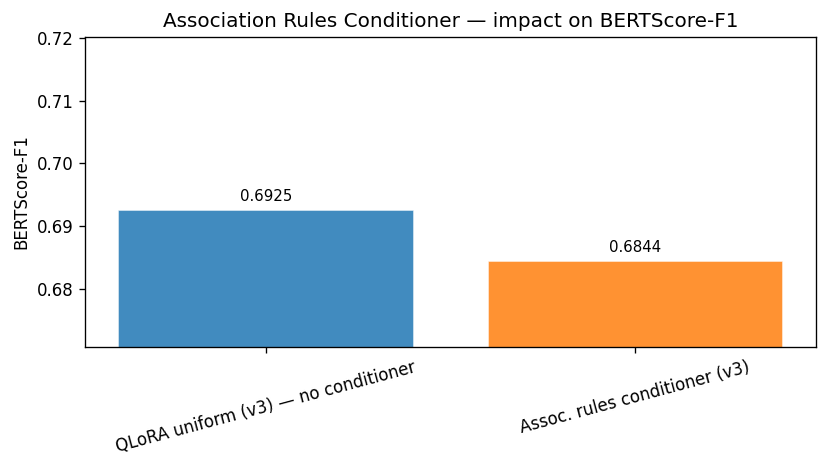

In [5]:
import bert_score.utils as _bsu
from bert_score import score as _bert_score
from src.data.labels import run_chexbert
from sklearn.metrics import f1_score
import evaluate as hf_evaluate

_orig_sent_encode = _bsu.sent_encode
def _safe_sent_encode(tokenizer, sent):
    if getattr(tokenizer, 'model_max_length', 0) > 10_000:
        tokenizer.model_max_length = 512
    return _orig_sent_encode(tokenizer, sent)
_bsu.sent_encode = _safe_sent_encode

_bleu  = hf_evaluate.load('bleu')
_rouge = hf_evaluate.load('rouge')

cache_m = REPO_ROOT / 'reports' / f'eval_metrics_{variant_key}.json'
if cache_m.exists():
    cond_metrics = json.loads(cache_m.read_text())
    print(f'Loaded metrics from {cache_m.name}')
else:
    refs = references
    print('BERTScore…')
    _, _, F = _bert_score(cond_hyps, refs,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    print('CheXbert…')
    hyp_labels = run_chexbert(cond_hyps, uncertain_policy='present', device=DEVICE)
    ref_labels = run_chexbert(refs,      uncertain_policy='present', device=DEVICE)
    print('BLEU/ROUGE…')
    cond_metrics = {
        'variant': variant_key,
        'bertscore_f1':      float(F.mean()),
        'chexbert_micro_f1': float(f1_score(ref_labels, hyp_labels, average='micro', zero_division=0)),
        'chexbert_macro_f1': float(f1_score(ref_labels, hyp_labels, average='macro', zero_division=0)),
        'bleu4':             _bleu.compute(predictions=cond_hyps, references=[[r] for r in refs], max_order=4)['bleu'],
        'rouge_l':           _rouge.compute(predictions=cond_hyps, references=refs)['rougeL'],
        'per_label_f1':      {label: float(f1_score(ref_labels[:, i], hyp_labels[:, i], zero_division=0))
                              for i, label in enumerate(CHEXBERT_LABELS)},
        'bertscore_per_study': F.tolist(),
    }
    cache_m.write_text(json.dumps(cond_metrics, indent=2))
    print(f'Saved → {cache_m.name}')

_bsu.sent_encode = _orig_sent_encode

# Load baseline for comparison
baseline_v3_path = REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json'
comparison = {}
if baseline_v3_path.exists():
    comparison['uniform_v3'] = json.loads(baseline_v3_path.read_text())
comparison[variant_key] = cond_metrics

DISPLAY_NAMES = {
    'uniform_v3':              'QLoRA uniform (v3) — no conditioner',
    'assoc_rules_uniform_v3':  'Assoc. rules conditioner (v3)',
}

rows = []
for v, m in comparison.items():
    rows.append({'Model': DISPLAY_NAMES.get(v, v),
                 'BERTScore-F1':      round(m['bertscore_f1'],      4),
                 'CheXbert micro-F1': round(m['chexbert_micro_f1'], 4),
                 'CheXbert macro-F1': round(m['chexbert_macro_f1'], 4),
                 'BLEU-4':            round(m['bleu4'],             4),
                 'ROUGE-L':           round(m['rouge_l'],           4)})
display(pd.DataFrame(rows).set_index('Model'))

if 'uniform_v3' in comparison:
    delta = cond_metrics['bertscore_f1'] - comparison['uniform_v3']['bertscore_f1']
    print(f'\nΔ BERTScore vs no-conditioner baseline: {delta:+.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
names  = [DISPLAY_NAMES.get(v, v) for v in comparison]
bscore = [comparison[v]['bertscore_f1'] for v in comparison]
colors = ['#1f77b4', '#ff7f0e']
bars   = ax.bar(names, bscore, color=colors[:len(comparison)], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bscore):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(bscore) * 0.98, max(bscore) * 1.04)
ax.set_ylabel('BERTScore-F1')
ax.set_title('Association Rules Conditioner — impact on BERTScore-F1')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eval_assoc_rules_comparison.png', dpi=150, bbox_inches='tight')
print('Saved eval_assoc_rules_comparison.png'); plt.show()

## STEP 6 — Per-indication analysis

Checks whether the conditioner helps specifically on the studies where a rule was triggered.

Studies that received a hint  : 241 (40.2%)
Studies with standard prompt  : 359 (59.8%)

BERTScore — hinted subset:
  Baseline (v3)  : 0.6990
  With conditioner: 0.6840
  Δ              : -0.0150

BERTScore — non-hinted subset:
  Baseline (v3)  : 0.6881
  With conditioner: 0.6847
  Δ              : -0.0035
Saved eval_assoc_rules_delta.png


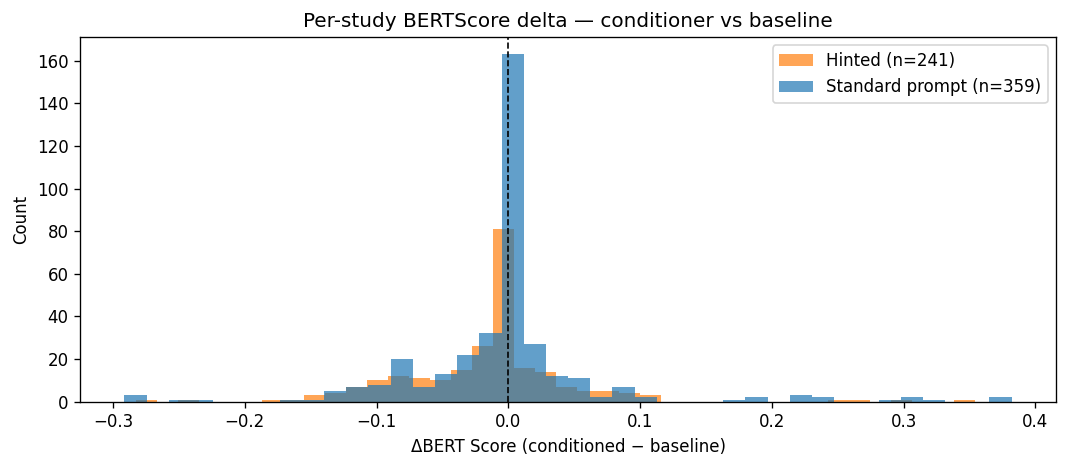

In [6]:
baseline_v3_path = REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json'
if not baseline_v3_path.exists():
    print('Run notebook 04 first to generate eval_metrics_uniform_v3.json')
else:
    base_scores  = np.array(json.loads(baseline_v3_path.read_text())['bertscore_per_study'])
    cond_scores  = np.array(cond_metrics['bertscore_per_study'])

    # Use _hint_fired (not keyword-only infer_likely_labels) so the mask accurately
    # reflects which studies received a hint under the two-tier mechanism.
    triggered_mask = np.array([
        _hint_fired(str(row.get('indication', '') or '').strip())
        for _, row in test_df.iterrows()
    ])

    n_trig   = triggered_mask.sum()
    n_notrig = (~triggered_mask).sum()

    print(f'Studies that received a hint  : {n_trig} ({100*n_trig/len(test_df):.1f}%)')
    print(f'Studies with standard prompt  : {n_notrig} ({100*n_notrig/len(test_df):.1f}%)')
    print()
    print('BERTScore — hinted subset:')
    print(f'  Baseline (v3)  : {base_scores[triggered_mask].mean():.4f}')
    print(f'  With conditioner: {cond_scores[triggered_mask].mean():.4f}')
    print(f'  Δ              : {(cond_scores - base_scores)[triggered_mask].mean():+.4f}')
    print()
    print('BERTScore — non-hinted subset:')
    print(f'  Baseline (v3)  : {base_scores[~triggered_mask].mean():.4f}')
    print(f'  With conditioner: {cond_scores[~triggered_mask].mean():.4f}')
    print(f'  Δ              : {(cond_scores - base_scores)[~triggered_mask].mean():+.4f}')

    delta_scores = cond_scores - base_scores
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(delta_scores[triggered_mask],  bins=40, alpha=0.7,
            label=f'Hinted (n={n_trig})',        color='#ff7f0e')
    ax.hist(delta_scores[~triggered_mask], bins=40, alpha=0.7,
            label=f'Standard prompt (n={n_notrig})', color='#1f77b4')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('ΔBERT Score (conditioned − baseline)')
    ax.set_ylabel('Count')
    ax.set_title('Per-study BERTScore delta — conditioner vs baseline')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eval_assoc_rules_delta.png', dpi=150, bbox_inches='tight')
    print('Saved eval_assoc_rules_delta.png'); plt.show()

Cargadas 600 hipótesis del caché (eval_hypotheses_nohint_uniform_v3.json)
Métricas cargadas del caché (eval_metrics_nohint_uniform_v3.json)


,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Condition,,,,,
v3 baseline (NB04 format),0.6925,0.4637,0.1651,0.1145,0.2915
v3 no-hint (NB06 format),0.6879,0.4404,0.1445,0.1128,0.2852
v3 + assoc. rules conditioner,0.6844,0.4424,0.1745,0.1100,0.2812



Δ vs baseline justo (NB06 format):
  BERTScore-F1          : -0.0035
  CheXbert micro-F1     : +0.0019
  CheXbert macro-F1     : +0.0301
  BLEU-4                : -0.0028
  ROUGE-L               : -0.0041

F1 por label rara (ESS < 160):


,v3 baseline,no-hint (fair),conditioned,Δ (cond − fair)
Label,,,,
Lung Lesion,0.000,0.000,0.000,0.000
Edema,0.000,0.000,0.222,0.222
Consolidation,0.000,0.000,0.000,0.000
Pneumonia,0.000,0.000,0.000,0.000
Pneumothorax,0.000,0.000,0.000,0.000
Pleural Effusion,0.308,0.286,0.345,0.059
Pleural Other,0.000,0.000,0.000,0.000
Fracture,0.258,0.069,0.062,-0.007
Support Devices,0.400,0.377,0.400,0.023


Saved assoc_rules_fair_comparison.png


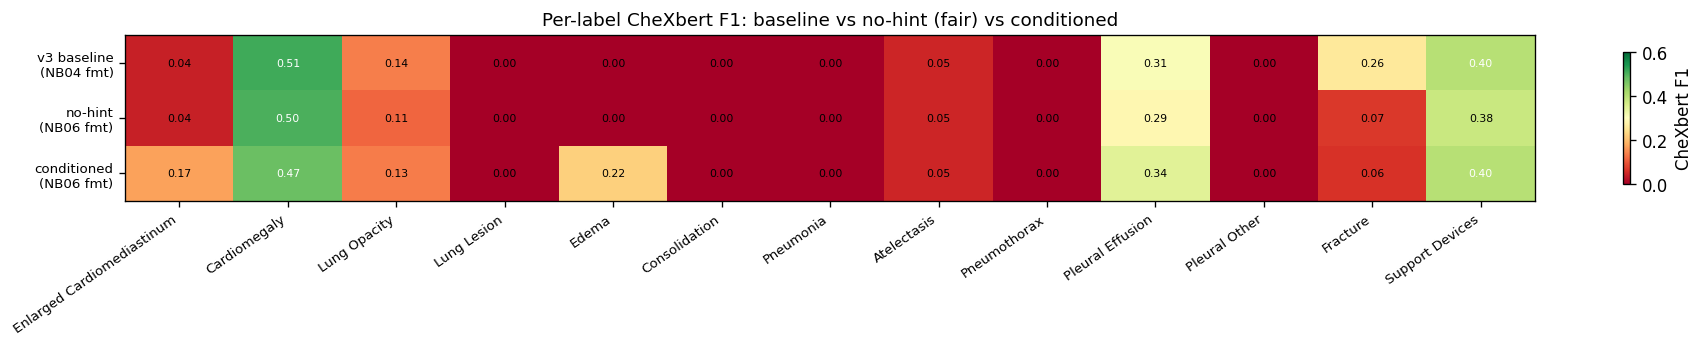

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Fair baseline: mismo formato que condicionado pero sin hint
#
# El baseline actual (eval_metrics_uniform_v3.json) usa el formato de NB04:
#   SYSTEM_PROMPT\nIndication: {indication}
# Las inferencias condicionadas usan build_conditioned_prompt que agrega \nFindings:
#   SYSTEM_PROMPT\nIndication: {indication}\nFindings:
#
# Esta celda corre la inferencia con el formato exacto de NB06 pero sin hint,
# para aislar el efecto causal del condicionador del efecto de formato.
# ══════════════════════════════════════════════════════════════════════════════

NOHINT_VARIANT = 'nohint_uniform_v3'
cache_nohint   = REPO_ROOT / 'reports' / f'eval_hypotheses_{NOHINT_VARIANT}.json'

def _build_plain_prompt(indication: str, system_prompt: str = '') -> str:
    """Mismo formato que build_conditioned_prompt pero sin hint — baseline justo."""
    parts = []
    if system_prompt:
        parts.append(system_prompt)
    if indication.strip():
        parts.append(f'Indication: {indication.strip()}')
    parts.append('Findings:')
    return '\n'.join(parts)

if cache_nohint.exists():
    nohint_hyps = json.loads(cache_nohint.read_text())
    print(f'Cargadas {len(nohint_hyps)} hipótesis del caché ({cache_nohint.name})')
else:
    print(f'Cargando {COND_VARIANT} para inferencia sin hint…')
    model, processor = load_model_and_processor(
        model_id=params['model']['base_model_id'],
        quantization=params['model']['quantization'],
    )
    adapter_path = CHECKPOINT_DIR / COND_VARIANT / 'best_model'
    if not adapter_path.exists():
        adapter_path = CHECKPOINT_DIR / f'qlora_{COND_VARIANT}' / 'best_model'
    model = PeftModel.from_pretrained(model, str(adapter_path))
    model.eval()

    nohint_hyps = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=NOHINT_VARIANT):
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''

        user_text = _build_plain_prompt(indication, system_prompt=SYSTEM_PROMPT)
        img = _load_image(row)
        content = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt = processor.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = processor(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model.generate(**inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False, pad_token_id=processor.tokenizer.eos_token_id)
        hyp = processor.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        nohint_hyps.append(hyp)

    cache_nohint.write_text(json.dumps(nohint_hyps, ensure_ascii=False, indent=2))
    del model, processor; torch.cuda.empty_cache()
    print(f'Guardadas {len(nohint_hyps)} hipótesis → {cache_nohint.name}')

# ── Métricas del baseline justo ───────────────────────────────────────────────
import bert_score.utils as _bsu2
from bert_score import score as _bert_score2
from sklearn.metrics import f1_score
import evaluate as hf_evaluate2

_orig2 = _bsu2.sent_encode
def _safe2(tokenizer, sent):
    if getattr(tokenizer, 'model_max_length', 0) > 10_000:
        tokenizer.model_max_length = 512
    return _orig2(tokenizer, sent)
_bsu2.sent_encode = _safe2

cache_m_nohint = REPO_ROOT / 'reports' / f'eval_metrics_{NOHINT_VARIANT}.json'
if cache_m_nohint.exists():
    nohint_metrics = json.loads(cache_m_nohint.read_text())
    print(f'Métricas cargadas del caché ({cache_m_nohint.name})')
else:
    _bleu2  = hf_evaluate2.load('bleu')
    _rouge2 = hf_evaluate2.load('rouge')
    print('BERTScore…')
    _, _, F2 = _bert_score2(nohint_hyps, references,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    print('CheXbert…')
    from src.data.labels import run_chexbert
    nh_hyp_labels = run_chexbert(nohint_hyps, uncertain_policy='present', device=DEVICE)
    nh_ref_labels = run_chexbert(references,   uncertain_policy='present', device=DEVICE)
    print('BLEU/ROUGE…')
    nohint_metrics = {
        'variant':           NOHINT_VARIANT,
        'bertscore_f1':      float(F2.mean()),
        'chexbert_micro_f1': float(f1_score(nh_ref_labels, nh_hyp_labels, average='micro', zero_division=0)),
        'chexbert_macro_f1': float(f1_score(nh_ref_labels, nh_hyp_labels, average='macro', zero_division=0)),
        'bleu4':             _bleu2.compute(predictions=nohint_hyps, references=[[r] for r in references], max_order=4)['bleu'],
        'rouge_l':           _rouge2.compute(predictions=nohint_hyps, references=references)['rougeL'],
        'per_label_f1':      {label: float(f1_score(nh_ref_labels[:, i], nh_hyp_labels[:, i], zero_division=0))
                              for i, label in enumerate(CHEXBERT_LABELS)},
        'bertscore_per_study': F2.tolist(),
    }
    cache_m_nohint.write_text(json.dumps(nohint_metrics, indent=2))
    print(f'Guardado → {cache_m_nohint.name}')

_bsu2.sent_encode = _orig2

# ── Tabla comparativa: 3 condiciones ─────────────────────────────────────────
RARE_LABELS = [l for l in CHEXBERT_LABELS
               if l not in ('No Finding', 'Lung Opacity', 'Cardiomegaly',
                            'Enlarged Cardiomediastinum', 'Atelectasis')]

METRIC_KEY = {
    'BERTScore-F1':      'bertscore_f1',
    'CheXbert micro-F1': 'chexbert_micro_f1',
    'CheXbert macro-F1': 'chexbert_macro_f1',
    'BLEU-4':            'bleu4',
    'ROUGE-L':           'rouge_l',
}

nb04_path = REPO_ROOT / 'reports' / 'eval_metrics_uniform_v3.json'
three_way = {
    'v3 baseline (NB04 format)':   json.loads(nb04_path.read_text()) if nb04_path.exists() else {},
    'v3 no-hint (NB06 format)':    nohint_metrics,
    'v3 + assoc. rules conditioner': cond_metrics,
}

rows = []
for label, m in three_way.items():
    if not m: continue
    rows.append({'Condition': label,
                 **{col: round(m[key], 4) for col, key in METRIC_KEY.items()}})
display(pd.DataFrame(rows).set_index('Condition'))

# Deltas vs baseline justo (NB06 format)
print('\nΔ vs baseline justo (NB06 format):')
for col, key in METRIC_KEY.items():
    ref = nohint_metrics[key]
    val = cond_metrics[key]
    print(f'  {col:<22}: {val - ref:+.4f}')

# ── Per-label F1: labels raras ────────────────────────────────────────────────
print('\nF1 por label rara (ESS < 160):')
rare_rows = []
for label in RARE_LABELS:
    rare_rows.append({
        'Label':          label,
        'v3 baseline':    round(json.loads(nb04_path.read_text())['per_label_f1'].get(label, 0), 3) if nb04_path.exists() else 0,
        'no-hint (fair)': round(nohint_metrics['per_label_f1'].get(label, 0), 3),
        'conditioned':    round(cond_metrics['per_label_f1'].get(label, 0), 3),
    })
rare_df = pd.DataFrame(rare_rows).set_index('Label')
rare_df['Δ (cond − fair)'] = (rare_df['conditioned'] - rare_df['no-hint (fair)']).round(3)
display(rare_df)

# ── Heatmap per-label: 3 condiciones ─────────────────────────────────────────
plot_labels = [l for l in CHEXBERT_LABELS if l != 'No Finding']
hm_data = np.array([
    [json.loads(nb04_path.read_text())['per_label_f1'].get(l, 0) for l in plot_labels] if nb04_path.exists() else [0]*len(plot_labels),
    [nohint_metrics['per_label_f1'].get(l, 0) for l in plot_labels],
    [cond_metrics['per_label_f1'].get(l, 0) for l in plot_labels],
])

fig, ax = plt.subplots(figsize=(16, 3))
im = ax.imshow(hm_data, cmap='RdYlGn', vmin=0, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(plot_labels)))
ax.set_xticklabels(plot_labels, rotation=35, ha='right', fontsize=8)
ax.set_yticks(range(3))
ax.set_yticklabels(['v3 baseline\n(NB04 fmt)', 'no-hint\n(NB06 fmt)', 'conditioned\n(NB06 fmt)'], fontsize=8)
for i in range(3):
    for j in range(len(plot_labels)):
        ax.text(j, i, f'{hm_data[i,j]:.2f}', ha='center', va='center',
                fontsize=6.5, color='black' if hm_data[i,j] < 0.4 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8, label='CheXbert F1')
ax.set_title('Per-label CheXbert F1: baseline vs no-hint (fair) vs conditioned', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'assoc_rules_fair_comparison.png', dpi=150, bbox_inches='tight')
print('Saved assoc_rules_fair_comparison.png')
plt.show()

In [8]:
# ─── STEP 8 — Combined RAG + Association Rules conditioner ─────────────────
# Uses the SAME TF-IDF index from step2 for both signals:
#   1. RAG: best-match findings text as style anchor (top-1, sim ≥ threshold)
#   2. Label prior: empirical P(label|indication) aggregated over top-k
#      with keyword fallback if TF-IDF prior is empty
# Prompt order: SYSTEM → example findings → label hint → Indication → Findings:

COMBINED_VARIANT        = f'rag_assoc_combined_{COND_VARIANT}'
cache_combined_hyps     = REPO_ROOT / 'reports' / f'eval_hypotheses_{COMBINED_VARIANT}.json'
_MIN_PREV_COMBINED      = 0.30


def build_combined_prompt(indication: str) -> str:
    """RAG style anchor + label prior hint, sharing the step2 TF-IDF index."""
    parts       = [SYSTEM_PROMPT]
    rag_example = None

    if indication.strip():
        q    = _rules_tfidf.transform([indication.strip()])
        sims = _cosine_sim(q, _rules_tfidf_matrix).flatten()
        if sims.max() >= _MIN_SIM_TFIDF:
            best = int(sims.argmax())
            rag_example = (train_df.iloc[best]['findings'] or '').strip()

    # Label hint: TF-IDF prior (primary) → keyword rules (fallback)
    priors     = retrieve_label_prior(indication)
    prior_hint = build_label_prior_hint(priors, min_prevalence=_MIN_PREV_COMBINED) if priors is not None else ''
    if prior_hint:
        hint = prior_hint
    else:
        kw_labels = infer_likely_labels(indication)
        hint = build_association_hint(kw_labels, rules_df,
                                      min_confidence=COND_MIN_CONF, min_lift=COND_MIN_LIFT)

    if rag_example:
        parts.append(f'Similar case findings:\n{rag_example}')
    if hint:
        parts.append(hint)
        parts.append('')
    if indication.strip():
        parts.append(f'Indication: {indication.strip()}')
    parts.append('Findings:')
    return '\n'.join(parts)


def _combined_rag_fired(indication: str) -> bool:
    """True if TF-IDF retrieval found at least one match above similarity threshold."""
    if not indication.strip():
        return False
    q    = _rules_tfidf.transform([indication.strip()])
    sims = _cosine_sim(q, _rules_tfidf_matrix).flatten()
    return bool(sims.max() >= _MIN_SIM_TFIDF)


# ── Smoke test ──────────────────────────────────────────────────────────────
_ex_ind = str(test_df.iloc[0].get('indication', '') or '').strip()
print('=== Combined prompt — smoke test ===')
print(build_combined_prompt(_ex_ind))
print('=' * 60)

n_rag  = sum(_combined_rag_fired(str(r.get('indication', '') or ''))
             for _, r in test_df.iterrows())
n_hint = sum(_hint_fired(str(r.get('indication', '') or ''))
             for _, r in test_df.iterrows())
print(f'RAG example  injected: {n_rag}/{len(test_df)}  ({100*n_rag/len(test_df):.1f}%)')
print(f'Label hint   injected: {n_hint}/{len(test_df)} ({100*n_hint/len(test_df):.1f}%)')


# ── Inference (cached) ──────────────────────────────────────────────────────
if cache_combined_hyps.exists():
    combined_hyps = json.loads(cache_combined_hyps.read_text())
    print(f'Loaded {len(combined_hyps)} cached hypotheses from {cache_combined_hyps.name}')
else:
    print(f'Loading {COND_VARIANT} for combined inference…')
    model, processor = load_model_and_processor(
        model_id=params['model']['base_model_id'],
        quantization=params['model']['quantization'],
    )
    adapter_path = CHECKPOINT_DIR / COND_VARIANT / 'best_model'
    if not adapter_path.exists():
        adapter_path = CHECKPOINT_DIR / f'qlora_{COND_VARIANT}' / 'best_model'
    model = PeftModel.from_pretrained(model, str(adapter_path))
    model.eval()

    combined_hyps = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=COMBINED_VARIANT):
        indication = str(row.get('indication', '') or '').strip()
        if indication.lower() in {'nan', 'none', ''}: indication = ''

        user_text = build_combined_prompt(indication)
        img       = _load_image(row)
        content   = [{'type': 'image'}, {'type': 'text', 'text': user_text}]
        prompt    = processor.apply_chat_template(
            [{'role': 'user', 'content': content}],
            add_generation_prompt=True, tokenize=False,
        )
        inputs = processor(text=prompt, images=[img], return_tensors='pt', padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model.generate(**inputs,
                max_new_tokens=params['model']['max_new_tokens'],
                do_sample=False, pad_token_id=processor.tokenizer.eos_token_id)
        hyp = processor.tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        combined_hyps.append(hyp)

    cache_combined_hyps.write_text(json.dumps(combined_hyps, ensure_ascii=False, indent=2))
    del model, processor; torch.cuda.empty_cache()
    print(f'Done. {len(combined_hyps)} hypotheses saved.')


# ── Metrics (cached) ────────────────────────────────────────────────────────
import bert_score.utils as _bsu
from bert_score import score as _bert_score
from src.data.labels import run_chexbert
from sklearn.metrics import f1_score
import evaluate as hf_evaluate

_orig_sent_encode_c8 = _bsu.sent_encode
def _safe_sent_encode_c8(tokenizer, sent):
    if getattr(tokenizer, 'model_max_length', 0) > 10_000:
        tokenizer.model_max_length = 512
    return _orig_sent_encode_c8(tokenizer, sent)
_bsu.sent_encode = _safe_sent_encode_c8

_bleu_c8  = hf_evaluate.load('bleu')
_rouge_c8 = hf_evaluate.load('rouge')

cache_combined_m = REPO_ROOT / 'reports' / f'eval_metrics_{COMBINED_VARIANT}.json'
if cache_combined_m.exists():
    combined_metrics = json.loads(cache_combined_m.read_text())
    print(f'Loaded metrics from {cache_combined_m.name}')
else:
    print('BERTScore…')
    _, _, F = _bert_score(combined_hyps, references,
        model_type=params['eval']['bertscore_model'],
        lang='en', device=DEVICE, verbose=False, batch_size=16)
    print('CheXbert…')
    hyp_labels = run_chexbert(combined_hyps, uncertain_policy='present', device=DEVICE)
    ref_labels = run_chexbert(references,    uncertain_policy='present', device=DEVICE)
    print('BLEU/ROUGE…')
    combined_metrics = {
        'variant':             COMBINED_VARIANT,
        'bertscore_f1':        float(F.mean()),
        'chexbert_micro_f1':   float(f1_score(ref_labels, hyp_labels, average='micro', zero_division=0)),
        'chexbert_macro_f1':   float(f1_score(ref_labels, hyp_labels, average='macro', zero_division=0)),
        'bleu4':               _bleu_c8.compute(predictions=combined_hyps,
                                                references=[[r] for r in references],
                                                max_order=4)['bleu'],
        'rouge_l':             _rouge_c8.compute(predictions=combined_hyps,
                                                 references=references)['rougeL'],
        'per_label_f1':        {label: float(f1_score(ref_labels[:, i], hyp_labels[:, i],
                                                       zero_division=0))
                                for i, label in enumerate(CHEXBERT_LABELS)},
        'bertscore_per_study': F.tolist(),
    }
    cache_combined_m.write_text(json.dumps(combined_metrics, indent=2))
    print(f'Saved → {cache_combined_m.name}')

_bsu.sent_encode = _orig_sent_encode_c8

# ── Four-way comparison ─────────────────────────────────────────────────────
DISPLAY_NAMES = {
    'nohint_uniform_v3':          'Fair baseline (no hint)',
    'rag_k3_uniform_v3':          'RAG k=3',
    'assoc_rules_uniform_v3':     'Assoc. rules conditioner',
    COMBINED_VARIANT:             'Combined RAG + Assoc. rules',
}

rows = []
for vk, label in DISPLAY_NAMES.items():
    p = REPO_ROOT / 'reports' / f'eval_metrics_{vk}.json'
    if not p.exists():
        continue
    m = json.loads(p.read_text())
    rows.append({
        'Model':             label,
        'BERTScore-F1':      round(m['bertscore_f1'],      4),
        'CheXbert micro-F1': round(m['chexbert_micro_f1'], 4),
        'CheXbert macro-F1': round(m['chexbert_macro_f1'], 4),
        'BLEU-4':            round(m['bleu4'],             4),
        'ROUGE-L':           round(m['rouge_l'],           4),
    })
display(pd.DataFrame(rows).set_index('Model'))

# Per-label rare pathology breakdown
rare = ['Edema', 'Consolidation', 'Pleural Other', 'Lung Lesion',
        'Pleural Effusion', 'Pneumonia', 'Support Devices']
print('\nPer-label F1 — rare pathologies:')
label_rows = []
for vk, label in DISPLAY_NAMES.items():
    p = REPO_ROOT / 'reports' / f'eval_metrics_{vk}.json'
    if not p.exists(): continue
    m = json.loads(p.read_text())
    row = {'Model': label}
    row.update({l: round(m.get('per_label_f1', {}).get(l, float('nan')), 3) for l in rare})
    label_rows.append(row)
display(pd.DataFrame(label_rows).set_index('Model'))

=== Combined prompt — smoke test ===
You are an expert radiologist. Write only the Findings section of a radiology report for the chest X-ray shown. Be concise and clinical. Do not include an Impression section.
Similar case findings:
Heart size within normal limits. Prominent right perihilar density consistent with lymphadenopathy, previously partially demonstrated XXXX abdomen and pelvis XXXX, XXXX. Negative for focal pulmonary consolidation, pleural effusion, or pneumothorax. TIPS noted.
Indication: XXXX-year-old XXXX with XXXX.
Findings:


INFO Loading processor from google/medgemma-4b-it
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"


RAG example  injected: 586/600  (97.7%)
Label hint   injected: 241/600 (40.2%)
Loading uniform_v3 for combined inference…


INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/chat_template.jinja "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO HTTP Request: GET https://huggingface.co/api/models/google/medgemma-4b-it/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: HEAD https://huggingface.co/google/medgemma-4b-it/resolve/main/processor_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggi

Done. 600 hypotheses saved.


...

INFO HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
INFO Running CheXbert on 600 texts (policy=present, device=cuda, batch=32)
INFO HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO HTTP Request: GET https://huggingface.co/api/models/b

BLEU/ROUGE…
Saved → eval_metrics_rag_assoc_combined_uniform_v3.json


,BERTScore-F1,CheXbert micro-F1,CheXbert macro-F1,BLEU-4,ROUGE-L
Model,,,,,
Fair baseline (no hint),0.6879,0.4404,0.1445,0.1128,0.2852
RAG k=3,0.7076,0.3432,0.1160,0.1391,0.3051
Assoc. rules conditioner,0.6844,0.4424,0.1745,0.1100,0.2812
Combined RAG + Assoc. rules,0.7033,0.2567,0.0954,0.1337,0.2870



Per-label F1 — rare pathologies:


,Edema,Consolidation,Pleural Other,Lung Lesion,Pleural Effusion,Pneumonia,Support Devices
Model,,,,,,,
Fair baseline (no hint),0.000,0.0,0.0,0.000,0.286,0.0,0.377
RAG k=3,0.000,0.0,0.0,0.133,0.160,0.0,0.211
Assoc. rules conditioner,0.222,0.0,0.0,0.000,0.345,0.0,0.400
Combined RAG + Assoc. rules,0.000,0.0,0.0,0.056,0.000,0.0,0.326


## Done

Metrics written to `reports/eval_metrics_assoc_rules_uniform_v3.json`.  
**Next:** return to notebook 04 STEP 7 and run the grand comparison cell — it will auto-discover
all `eval_metrics_*.json` files including RAG (05) and association rules (06).